# Big Data Analytics

Group 13

- Beatris Daicu, 20221854
- Diogo Carvalho, 20221935
- Ricardo Pereira, 20250343
- Yehor Malakhov, 20221691

# Imports

Importing Libraries that are to be used


In [1]:
import os
from itertools import chain

import matplotlib.pyplot as plt
import networkx as nx
from graphframes import GraphFrame
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count_distinct, create_map, lit

In [2]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk-amd64"

spark = (
    SparkSession.builder.appName("GraphFramesWithSpark4")
    .config(
        "spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.11.0"
    )
    .getOrCreate()
)

sc = spark.sparkContext

:: loading settings :: url = jar:file:/workspaces/bdaG13/.venv/lib/python3.14/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/user/.ivy2.5.2/cache
The jars for the packages stored in: /home/user/.ivy2.5.2/jars
io.graphframes#graphframes-spark4_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f9d84d5c-474a-4fb0-8f82-bb5f0c044056;1.0
	confs: [default]
	found io.graphframes#graphframes-spark4_2.13;0.11.0 in central
	found io.graphframes#graphframes-graphx-spark4_2.13;0.11.0 in central
downloading https://repo1.maven.org/maven2/io/graphframes/graphframes-spark4_2.13/0.11.0/graphframes-spark4_2.13-0.11.0.jar ...
	[SUCCESSFUL ] io.graphframes#graphframes-spark4_2.13;0.11.0!graphframes-spark4_2.13.jar (116ms)
downloading https://repo1.maven.org/maven2/io/graphframes/graphframes-graphx-spark4_2.13/0.11.0/graphframes-graphx-spark4_2.13-0.11.0.jar ...
	[SUCCESSFUL ] io.graphframes#g

In [3]:
# GraphFrames connected components requires a checkpoint directory
sc.setCheckpointDir("../tmp/graphframes-checkpoints")

spark.conf.set("spark.sql.shuffle.partitions", "16")

# EDA

Firstly, let's import our data


In [4]:
links_path = "../data/links_export.csv"
pages_path = "../data/pages_export.csv"


links_raw = spark.read.csv(
    links_path, header=True, inferSchema=True, multiLine=True, escape='"'
)
pages_raw = spark.read.csv(
    pages_path, header=True, inferSchema=True, multiLine=True, escape='"'
)

Let's see schema and first rows of our dataframes


In [5]:
links_raw.printSchema()
pages_raw.printSchema()

root
 |-- id: integer (nullable = true)
 |-- source_title: string (nullable = true)
 |-- target_title: string (nullable = true)
 |-- language: string (nullable = true)
 |-- position: integer (nullable = true)
 |-- depth: integer (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- source_url: string (nullable = true)
 |-- target_url: string (nullable = true)

root
 |-- id: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- language: string (nullable = true)
 |-- content_length: integer (nullable = true)
 |-- word_count: integer (nullable = true)
 |-- categories: string (nullable = true)
 |-- infobox: string (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- url: string (nullable = true)



In [6]:
links_raw.show(3, truncate=80)
print("\n")
pages_raw.show(3, truncate=80)

+---+---------------------+---------------------------+--------+--------+-----+-------------------+---------------------------------------------------+---------------------------------------------------------+
| id|         source_title|               target_title|language|position|depth|         created_at|                                         source_url|                                               target_url|
+---+---------------------+---------------------------+--------+--------+-----+-------------------+---------------------------------------------------+---------------------------------------------------------+
|  1|The Loner (TV series)|20th Century-Fox Television|      en|       0|    1|2025-11-29 21:03:28|https://en.wikipedia.org/wiki/The_Loner_(TV_series)|https://en.wikipedia.org/wiki/20th_Century-Fox_Television|
|  2|The Loner (TV series)|                  Al Checco|      en|       1|    1|2025-11-29 21:03:28|https://en.wikipedia.org/wiki/The_Loner_(TV_series)|         

As the language for the whole dataframe is english, and we do not preocupy with
timestamps or the depth at which data was encountered we will limit information
on vertices and edges to minimum. We also will not use categories as many of
them either too specific or too general which would require some text mining to
find meaningfull ones which is not the topic of this project.


In [7]:
vertices = (
    pages_raw.withColumn("id", F.col("id").cast("string"))
    .withColumn("name", F.col("title"))
    .select(
        [
            "id",
            "name",
            # "categories",
            "word_count",
            "url",
        ]
    )
)

edges = (
    links_raw.select(["source_title", "target_title"])
    .join(
        vertices.withColumn("src", F.col("id")).select(["src", "name"]),
        (links_raw.source_title == vertices.name),
        how="inner",
    )
    .drop("name")
    .join(
        vertices.withColumn("dst", F.col("id")).select(["dst", "name"]),
        (links_raw.target_title == vertices.name),
        how="inner",
    )
    .select(["src", "dst"])
)

As you can see, we kept only the ids, names and urls for the vertices, and only
ids os source and target for the edges.


In [8]:
vertices.show(3, truncate=80)
edges.show(3, truncate=80)

+---+------------------------------+----------+------------------------------------------------------------+
| id|                          name|word_count|                                                         url|
+---+------------------------------+----------+------------------------------------------------------------+
|  1|         The Loner (TV series)|      1804|         https://en.wikipedia.org/wiki/The_Loner_(TV_series)|
|  2|                She's a Hottie|       923|                https://en.wikipedia.org/wiki/She's_a_Hottie|
|  3|Point of No Return (TV series)|       992|https://en.wikipedia.org/wiki/Point_of_No_Return_(TV_series)|
+---+------------------------------+----------+------------------------------------------------------------+
only showing top 3 rows


+---+-----+
|src|  dst|
+---+-----+
|628|  639|
|628| 9499|
|628|21924|
+---+-----+
only showing top 3 rows


Now let's process this data as a graph


In [9]:
g = GraphFrame(vertices, edges)

print("GraphFrame created.")
print("Vertices:", g.vertices.count())
print("Edges:", g.edges.count())

GraphFrame created.
Vertices: 100000


Edges: 8577044


Let's check the degrees of the vertices


In [10]:
degrees = g.degrees
in_degrees = g.inDegrees
out_degrees = g.outDegrees

degree_summary = (
    g.vertices.join(degrees, on="id", how="left")
    .join(in_degrees, on="id", how="left")
    .join(out_degrees, on="id", how="left")
    .fillna({"degree": 0, "inDegree": 0, "outDegree": 0})
)

degree_summary.cache()

# display
degree_summary.select("id", "name", "degree", "inDegree", "outDegree").orderBy(
    F.desc("degree")
).show(10, truncate=80)

degree_summary.select("id", "name", "degree", "inDegree", "outDegree").orderBy(
    F.desc("inDegree")
).show(10, truncate=80)

degree_summary.select("id", "name", "degree", "inDegree", "outDegree").orderBy(
    F.desc("outDegree")
).show(10, truncate=80)

+-----+--------------------+------+--------+---------+
|   id|                name|degree|inDegree|outDegree|
+-----+--------------------+------+--------+---------+
| 1248|   ISBN (identifier)| 51721|   51535|      186|
| 1087|    Doi (identifier)| 31615|   31462|      153|
| 1443|     Wayback Machine| 24362|   24295|       67|
|42744|   ISSN (identifier)| 23450|   23311|      139|
| 1543|  S2CID (identifier)| 17855|   17820|       35|
| 1010|Bibcode (identifier)| 12405|   12397|        8|
|45194|   OCLC (identifier)| 11915|   11888|       27|
|12020|  JSTOR (identifier)| 11281|   11254|       27|
|28525|   PMID (identifier)|  9949|    9912|       37|
|14867|           Time zone|  9624|    9293|      331|
+-----+--------------------+------+--------+---------+
only showing top 10 rows
+-----+--------------------+------+--------+---------+
|   id|                name|degree|inDegree|outDegree|
+-----+--------------------+------+--------+---------+
| 1248|   ISBN (identifier)| 51721|   51

As you can see above the nodes with highest degree centrality, as well as in
degrees, are nodes with tecnical terms, which probably get referenced as types
of references themselves. At the same time the nodes with the highest out
degrees are historical and political pages, most likey referencing multimple
related historical and political pages.

Now let's plot degree distribution:


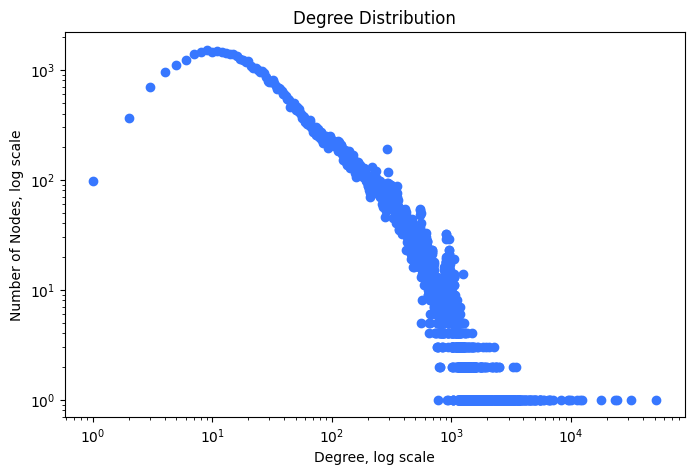

In [11]:
degree_distribution = degree_summary.groupBy("degree").count().orderBy("degree")

degree_pd = degree_distribution.orderBy("degree").toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(degree_pd["degree"], degree_pd["count"], c="#3777FF")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Degree, log scale")
plt.ylabel("Number of Nodes, log scale")
plt.title("Degree Distribution")
plt.show()

As we can see from the graph most pages about 10 references from or to them, at
the same time the graph shows a tale of small amount of points with a very high
degree.

In regards of graphs density, we can see that it is quite sparse.


In [12]:
num_vertices = g.vertices.count()
num_edges = g.edges.count()

density_directed = (
    num_edges / (num_vertices * (num_vertices - 1)) if num_vertices > 1 else 0
)

print(f"Number of vertices: {num_vertices:,}")
print(f"Number of edges: {num_edges:,}")
print(f"Directed graph density: {density_directed:.12f}")

Number of vertices: 100,000
Number of edges: 8,577,044
Directed graph density: 0.000857712977


# Centrality

To calculate centrality metrics we decided to use a sample of the graph, to be
exact a 2.5% of original number of vertices to havce more efficient calculations
and somewhat clearer visualisations.


In [13]:
sampled_vertices = g.vertices.sample(False, 0.025, seed=42)

ids = [r.id for r in sampled_vertices.select("id").collect()]

sampled_edges = g.edges.filter(
    (F.col("src").isin(ids)) & (F.col("dst").isin(ids))
)

g_sample = GraphFrame(sampled_vertices, sampled_edges)

To calculate betweeness centrality we decided to use NetworkX


In [14]:
# Summarize results for betweenness centrality
nxg = nx.DiGraph(
    nx.from_pandas_edgelist(g_sample.edges.toPandas(), "src", "dst")
)
bc = nx.betweenness_centrality(nxg)

Let's now visualise the calculated betweeness centrality results. To magnify the
differences both color and size will represent the obtained measurements.


In [15]:
node_list = nx.nodes(nxg)
node_color_list = [bc.get(node) for node in node_list]
pos = nx.kamada_kawai_layout(nxg)

order_df = spark.createDataFrame(
    [(nid, idx) for idx, nid in enumerate(node_list)], ["id", "order_col"]
)

word_counts = (
    order_df.join(vertices, on="id", how="left")
    .orderBy("order_col")
    .select("word_count")
    .rdd.flatMap(lambda x: x)
    .collect()
)

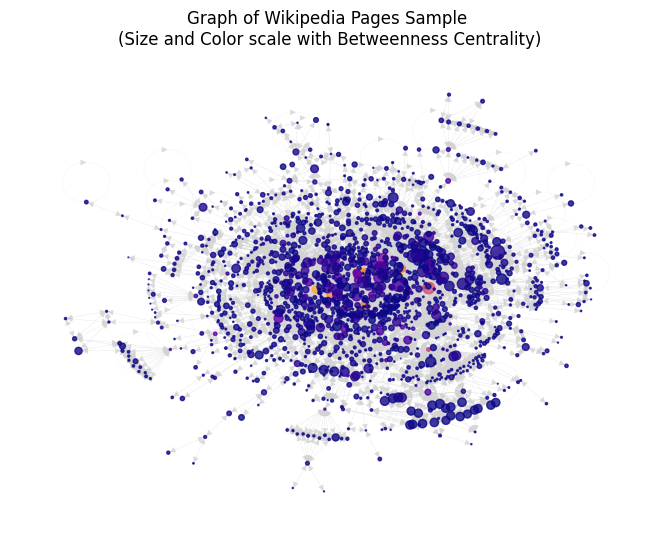

In [16]:
nx.draw(
    nxg,
    pos=pos,
    node_color=node_color_list,
    node_size=[
        w / 500 for w in word_counts
    ],  # list(map(lambda x: x*5000, node_color_list)),
    width=0.1,
    alpha=0.8,
    cmap="plasma",
    edge_color="#d3d3d3",
)
plt.title(
    "Graph of Wikipedia Pages Sample \n(Size and Color scale with Betweenness Centrality)"
)
plt.show()

Let's now see what are the nodes with highest betweenness centrality


In [17]:
mapping_expr = create_map([lit(x) for x in chain(*bc.items())])

sampled_vertices.withColumn(
    "betweenness_centrality", mapping_expr[col("id")]
).sort("betweenness_centrality", ascending=False).show(10)

+-----+--------------------+----------+--------------------+----------------------+
|   id|                name|word_count|                 url|betweenness_centrality|
+-----+--------------------+----------+--------------------+----------------------+
|50160|            BBC News|     12586|https://en.wikipe...|   0.12329695055668226|
|38989|     German language|     16432|https://en.wikipe...|   0.10129639874549937|
|32890|         Philippines|     37663|https://en.wikipe...|    0.0987144692770326|
|31270|     French language|     18045|https://en.wikipe...|    0.0927123559341875|
|51412|         Sunni Islam|     21140|https://en.wikipe...|   0.08744308487894728|
|26470|                 CNN|     14059|https://en.wikipe...|   0.08239018642011625|
|29895|         The Beatles|     35814|https://en.wikipe...|   0.06650518079217978|
| 1376|Orbital eccentricity|      3313|https://en.wikipe...|  0.060087609370445196|
|21292|            Religion|     22034|https://en.wikipe...|   0.05579146300

# Communities

Now let's see if there are communities within the graph


In [18]:
result = g_sample.labelPropagation(maxIter=5)
result.show()

+-----+--------------------+----------+--------------------+------------+
|   id|                name|word_count|                 url|       label|
+-----+--------------------+----------+--------------------+------------+
| 1192|         Ellipsoidal|      5959|https://en.wikipe...|          43|
| 1471|             Neptune|     14954|https://en.wikipe...| 17179869192|
| 1896|         Rotoscoping|      2537|https://en.wikipe...|111669149790|
| 1905|Architecture of t...|       929|https://en.wikipe...|  8589934603|
| 2199|Economic history ...|     22080|https://en.wikipe...|           1|
| 2329|Book of Royal Deg...|       342|https://en.wikipe...|120259084313|
| 2340|       Thermodynamic|      7140|https://en.wikipe...|          39|
| 3200|        Scottish art|     12114|https://en.wikipe...|111669149809|
| 5153|2016 Azerbaijani ...|       604|https://en.wikipe...| 60129542213|
| 5602|           Militsiya|      4406|https://en.wikipe...| 34359738490|
| 5730|          Ceilometer|      1659

26/06/03 12:40:27 WARN LabelPropagation: Returned DataFrame is persistent and materialized!


As the result shows there are in total 1373 different groups, however from the
next graph it gets obvious that most of them just contains individual vertices.


In [19]:
result = g_sample.labelPropagation(maxIter=5)
result.select(count_distinct(result.label)).show()

+---------------------+
|count(DISTINCT label)|
+---------------------+
|                 1357|
+---------------------+



26/06/03 12:40:29 WARN LabelPropagation: Returned DataFrame is persistent and materialized!


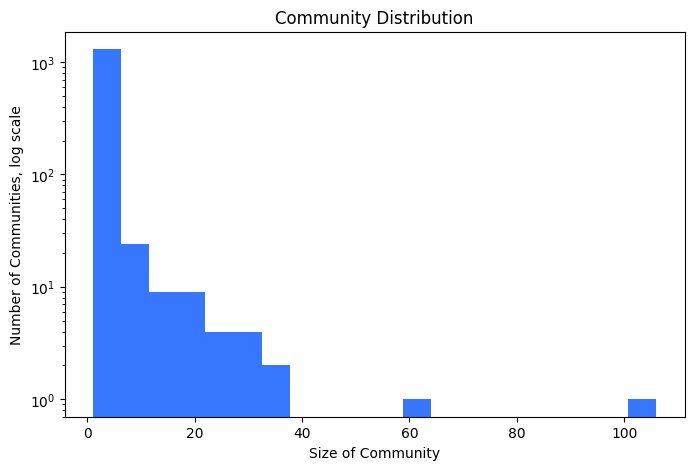

In [20]:
community_distribution = (
    result.groupBy("label").count().sort("count", ascending=False)
)

community_pd = community_distribution.toPandas()

plt.figure(figsize=(8, 5))
plt.hist(community_pd["count"], color="#3777FF", bins=20)
plt.yscale("log")
plt.xlabel("Size of Community")
plt.ylabel("Number of Communities, log scale")
plt.title("Community Distribution")
plt.show()

Let's explore the biggest 3 communities to understand what they are.


In [21]:
mapping_expr = create_map([lit(x) for x in chain(*bc.items())])

for i in range(3):
    main_community = (
        result.filter(f"label=={community_distribution.collect()[i].label}")
        .withColumn("bc", mapping_expr[col("id")])
        .sort("bc", ascending=False)
        .select(["id", "name", "url"])
    )

    main_community.show(10, truncate=80)

+-----+-----------------------+-----------------------------------------------------+
|   id|                   name|                                                  url|
+-----+-----------------------+-----------------------------------------------------+
|38989|        German language|        https://en.wikipedia.org/wiki/German_language|
|31270|        French language|        https://en.wikipedia.org/wiki/French_language|
|96320|                  CcTLD|                  https://en.wikipedia.org/wiki/CcTLD|
|26678|            Ivory Coast|            https://en.wikipedia.org/wiki/Ivory_Coast|
|28053|Commonwealth of Nations|https://en.wikipedia.org/wiki/Commonwealth_of_Nations|
|13781|                  Delhi|                  https://en.wikipedia.org/wiki/Delhi|
|41521|            Isle of Man|            https://en.wikipedia.org/wiki/Isle_of_Man|
|36855|                Burundi|                https://en.wikipedia.org/wiki/Burundi|
|35975|                Dialect|                https:/

As we can see the three biggest communities are as could be expected ones which
often reference each other, specifically Music Industry, Astronomical Concepts
and Bodies and Religious Ideas. Let's now visiualise the location of the first
one


/workspaces/bdaG13/.venv/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


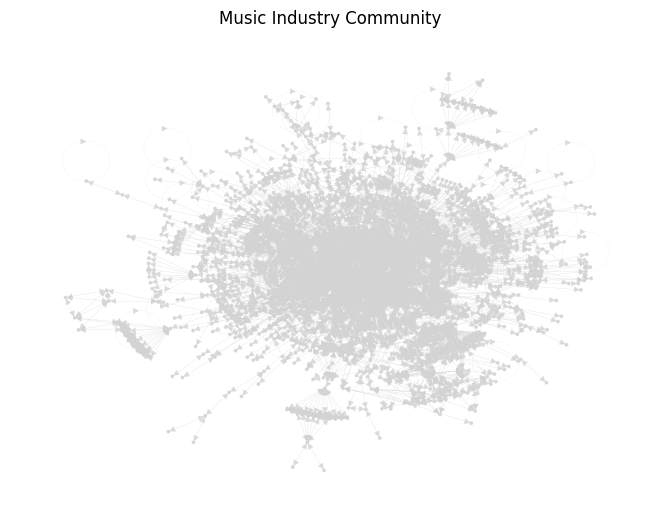

In [22]:
node_color_list = [
    result.filter(f"id=={node}").collect()[0].label for node in node_list
]

node_color_list = [
    "#d3d3d3" if val != 181 else "#0ee071" for val in node_color_list
]

nx.draw(
    nxg,
    pos=pos,
    node_color=node_color_list,
    node_size=3,
    width=0.1,
    alpha=0.8,
    cmap="YlGn",
    edge_color="#d3d3d3",
)
plt.title("Music Industry Community")
plt.show()

# Motifs

Most interesting motif for us in the wikipedia are the loops, we want to see
examples of self referencing pages and pairs of pages that reference each other.


In [23]:
loops = g_sample.find("(a)-[e1]->(a)")
loops.show(10, truncate=80)

+--------------------------------------------------------------------------------+--------------+
|                                                                               a|            e1|
+--------------------------------------------------------------------------------+--------------+
|{17112, Romans in the Netherlands, 3372, https://en.wikipedia.org/wiki/Romans...|{17112, 17112}|
|             {19880, Knot genus, 1563, https://en.wikipedia.org/wiki/Knot_genus}|{19880, 19880}|
|{43733, Abul Wafa Al Afghani, 3569, https://en.wikipedia.org/wiki/Abul_Wafa_A...|{43733, 43733}|
|           {59922, Meja ambush, 3261, https://en.wikipedia.org/wiki/Meja_ambush}|{59922, 59922}|
|        {75925, We Rock (DVD), 607, https://en.wikipedia.org/wiki/We_Rock_(DVD)}|{75925, 75925}|
|{81446, China Vegan Society, 3216, https://en.wikipedia.org/wiki/China_Vegan_...|{81446, 81446}|
|{86835, Paganism (contemporary), 22338, https://en.wikipedia.org/wiki/Paganis...|{86835, 86835}|
|                   

In [24]:
callers = g_sample.find("(a)-[e1]->(b); (b)-[e2]->(a)").filter("a.id < b.id")
callers.select(["a", "b"]).show(10, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                               a|                                                                               b|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|             {23899, Wolf 1061c, 1759, https://en.wikipedia.org/wiki/Wolf_1061c}|{28773, 2015 Thailand bolide, 1179, https://en.wikipedia.org/wiki/2015_Thaila...|
|{43733, Abul Wafa Al Afghani, 3569, https://en.wikipedia.org/wiki/Abul_Wafa_A...|{45364, Shakarim Qudayberdiuli, 2938, https://en.wikipedia.org/wiki/Shakarim_...|
|{26257, List of sultans of Zanzibar, 2614, https://en.wikipedia.org/wiki/List...|{40409, Tanzanian literature, 1194, https://en.wikipedia.org/wiki/Tanzanian_l...|
|  {20222, Roman